# Modelo Lineal

In [1]:
%cd ..

c:\Users\juanw\Desktop\garbage-classification


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.carga import cargar_datos
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import os

## Carga de los datos

In [3]:
root = 'data/Garbage-classification/Garbage-classification/'
df = cargar_datos(root)
df.head()

,x,y
2454,data/Garbage-classification/Garbage-classifica...,trash
274,data/Garbage-classification/Garbage-classifica...,cardboard
430,data/Garbage-classification/Garbage-classifica...,glass
53,data/Garbage-classification/Garbage-classifica...,cardboard
2437,data/Garbage-classification/Garbage-classifica...,trash


## Division de los datos

In [4]:
from sklearn.model_selection import train_test_split

# 80% train, 20% (test + validación)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['y']
 )

# Del 20% (test + validacion): 10% validación y 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['y']
 )

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validación: {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test: {len(test_df)} ({len(test_df)/len(df):.1%})")

Train: 2021 (80.0%)
Validación: 253 (10.0%)
Test: 253 (10.0%)


## Modificacion de las imagenes y carga en memoria.

Al aplicar modelos lineales los cuales no tienen como argumento el batch_size tenemos que hacer la carga de todas las imagenes en memoria y transformarlas a un vector unico por imagen para poder darselas al modelo.

In [5]:
def load_images(df, size):
    images = []
    labels = []
    
    for _, row in df.iterrows():
        ruta = row['x']
        label = row['y']
        
        img = cv2.imread(ruta)                  
        img = cv2.resize(img, (size, size))    
        img = img.astype('float32') / 255.0    
        
        images.append(img)
        labels.append(label)
    
    X = np.array(images)
    y = np.array(labels)
    
    return X, y

In [6]:
x_train, y_train = load_images(train_df, size=128)
x_val, y_val = load_images(val_df, size=128)
x_test, y_test = load_images(test_df, size=128)

In [7]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((2021, 128, 128, 3),
 (2021,),
 (253, 128, 128, 3),
 (253,),
 (253, 128, 128, 3),
 (253,))

Aplanamos las imagenes para poder pasarle al modelo lineal cada imagen como un vector unico

In [8]:
X_train = x_train.reshape(x_train.shape[0], -1)
X_val   = x_val.reshape(x_val.shape[0], -1)
X_test  = x_test.reshape(x_test.shape[0], -1)

One-hot encoding para los lebels

In [9]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val  = le.transform(y_val)
y_test  = le.transform(y_test)

In [10]:
le.classes_

array(['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'],
      dtype='<U9')

## Aplicamos el modelo de clasificación

In [18]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [19]:
# Predicciones
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)



In [25]:
print(classification_report(y_train, y_train_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   cardboard       1.00      1.00      1.00       322
       glass       1.00      1.00      1.00       401
       metal       1.00      1.00      1.00       328
       paper       1.00      1.00      1.00       475
     plastic       1.00      1.00      1.00       385
       trash       1.00      1.00      1.00       110

    accuracy                           1.00      2021
   macro avg       1.00      1.00      1.00      2021
weighted avg       1.00      1.00      1.00      2021



In [26]:
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   cardboard       0.45      0.55      0.49        40
       glass       0.38      0.46      0.42        50
       metal       0.50      0.34      0.41        41
       paper       0.63      0.45      0.52        60
     plastic       0.48      0.50      0.49        48
       trash       0.13      0.21      0.16        14

    accuracy                           0.45       253
   macro avg       0.43      0.42      0.42       253
weighted avg       0.47      0.45      0.45       253



In [20]:


print(classification_report(y_test, y_test_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   cardboard       0.65      0.54      0.59        41
       glass       0.30      0.42      0.35        50
       metal       0.34      0.24      0.29        41
       paper       0.54      0.46      0.50        59
     plastic       0.44      0.53      0.48        49
       trash       0.30      0.23      0.26        13

    accuracy                           0.43       253
   macro avg       0.43      0.40      0.41       253
weighted avg       0.45      0.43      0.43       253



In [21]:
def plot_confusion(y_true, y_pred, class_names, title='Matriz de confusion'):
    # Redondear predicciones a etiquetas enteras
    y_pred_labels = np.rint(y_pred).astype(int)
    y_pred_labels = np.clip(y_pred_labels, 0, len(class_names) - 1)

    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred_labels, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.tight_layout()
    plt.show()



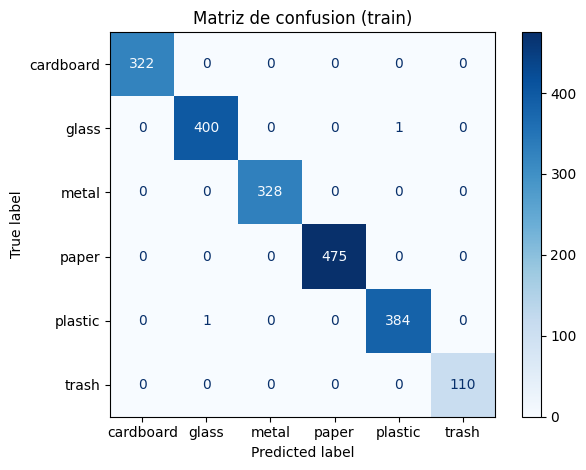

In [22]:
plot_confusion(y_train, y_train_pred, le.classes_, title='Matriz de confusion (train)')

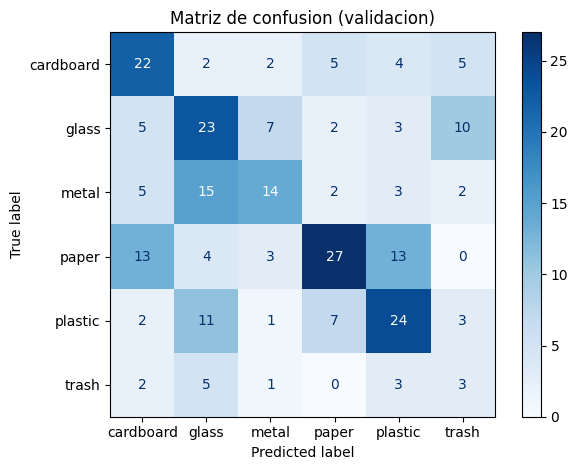

In [23]:
plot_confusion(y_val, y_val_pred, le.classes_, title='Matriz de confusion (validacion)')

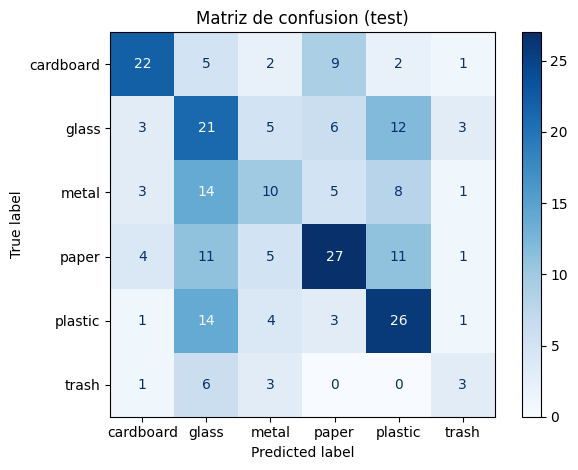

In [24]:
plot_confusion(y_test, y_test_pred, le.classes_, title='Matriz de confusion (test)')